# Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import rasterio

# Importing file

In [2]:
file = "/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/2_Image_and_Resolution/data/NDVI_export.tif"

In [3]:
with rasterio.open(file) as src:
   ndvi = src.read(1)

# Visualize Array

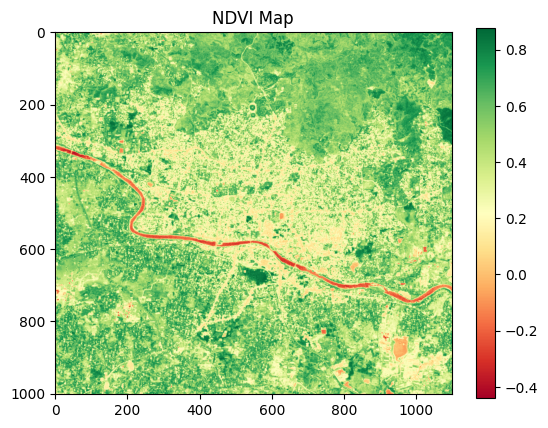

In [4]:
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.visual_ndvi import vis_ndvi

vis_ndvi(ndvi)

In [7]:
with rasterio.open(file) as src:
   print("CRS:", src.crs)
   print("Resolution:", src.res)
   print("Shape:", src.read().shape)

CRS: EPSG:4326
Resolution: (8.983152841195215e-05, 8.983152841195215e-05)
Shape: (1, 1002, 1098)


# Downsampling

## Method 1 - ARRAY SLICING

In [8]:
small = ndvi[::2, ::2]

## Compare

### Shape


In [9]:
print(ndvi.shape)
print(small.shape)

(1002, 1098)
(501, 549)


### Visual

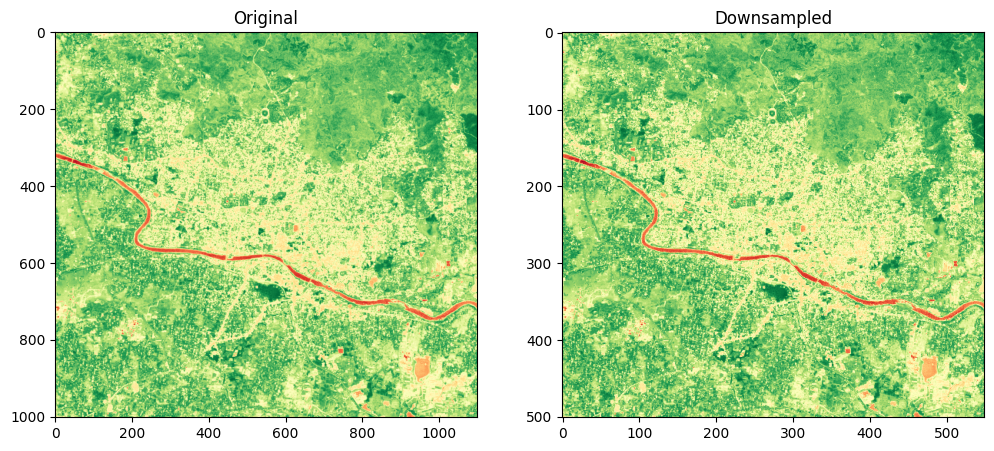

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].imshow(ndvi, cmap='RdYlGn')
ax[0].set_title("Original")

ax[1].imshow(small, cmap='RdYlGn')
ax[1].set_title("Downsampled")

plt.show()


## Method 2 - TRUE RESAMPLING USING SCIPY

In [12]:
from scipy.ndimage import zoom

small2 = zoom(ndvi, 0.5)  # Reduced size to 50 percent

# Upsampling

In [13]:
large = zoom(ndvi, 2)

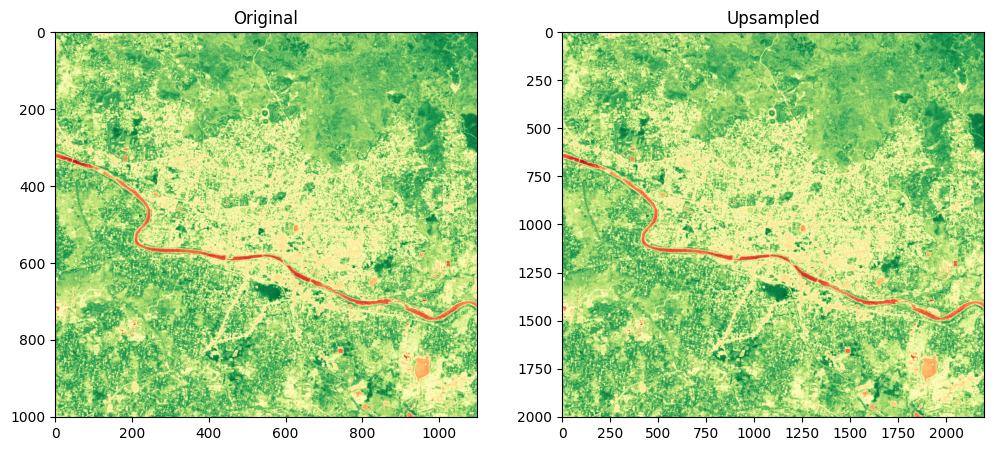

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].imshow(ndvi, cmap='RdYlGn')
ax[0].set_title("Original")

ax[1].imshow(large, cmap='RdYlGn')
ax[1].set_title("Upsampled")

plt.show()
